In [7]:
# Workspace User Engagement Analysis

## Project Objective

## This project demonstrates an end-to-end data analytics workflow using SQLite and Python. The analysis focuses on data cleaning, SQL querying, and business insights from customer engagement and logistics data.

## 1. Import Libraries

import sqlite3
import pandas as pd

# Upload file if not already uploaded
from google.colab import files
uploaded = files.upload()

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(filename)

# Create SQLite database
conn = sqlite3.connect("workspace_engagement.db")

# Save data as SQL table
df.to_sql("user_sessions", conn, if_exists="replace", index=False)

print("✅ Database created successfully!")
print(df.head())

Saving ecommerce_logistics.csv to ecommerce_logistics.csv
✅ Database created successfully!
     customer_id  customer_age  account_age_months customer_segment  \
0  CUST-741605EE            47                  77         Standard   
1  CUST-2E961085            37                  84         Standard   
2  CUST-AB491CB0            49                  83         Standard   
3  CUST-ED39BF5B            62                  79         Standard   
4  CUST-E7BE67D0            36                 115         Standard   

  location_type      order_id product_category  item_price_usd  quantity  \
0         Urban  ORD-C6515EA8         Clothing           46.92         2   
1         Urban  ORD-6D7DCEBA         Clothing           42.54         4   
2      Suburban  ORD-7D996699         Clothing          140.61         1   
3         Rural  ORD-35A5E670             Toys           29.98         1   
4         Urban  ORD-8FC091D5        Groceries           10.27         2   

   total_order_value_usd 

In [8]:
## 2. Load Dataset

query = """
SELECT *
FROM user_sessions
LIMIT 10;
"""

pd.read_sql(query, conn)

,customer_id,customer_age,account_age_months,customer_segment,location_type,order_id,product_category,item_price_usd,quantity,total_order_value_usd,...,shipping_method,weather_conditions_at_dispatch,carrier_type,estimated_delivery_days,actual_delivery_days,delivery_delay_days,delivery_status,customer_review_score,product_returned,fraud_flag
0,CUST-741605EE,47,77,Standard,Urban,ORD-C6515EA8,Clothing,46.92,2,93.83,...,Standard,Clear,Internal_Fleet,3.0,5.4,2.4,Late,4,No,No
1,CUST-2E961085,37,84,Standard,Urban,ORD-6D7DCEBA,Clothing,42.54,4,170.17,...,Standard,Snow,Third_Party_Air,3.0,4.5,1.5,Late,3,No,No
2,CUST-AB491CB0,49,83,Standard,Suburban,ORD-7D996699,Clothing,140.61,1,140.61,...,Standard,Clear,Internal_Fleet,3.0,2.1,-0.9,Cancelled,5,No,No
3,CUST-ED39BF5B,62,79,Standard,Rural,ORD-35A5E670,Toys,29.98,1,29.98,...,Standard,Rain,Third_Party_Ground,3.0,6.5,3.5,Late,4,No,No
4,CUST-E7BE67D0,36,115,Standard,Urban,ORD-8FC091D5,Groceries,10.27,2,20.54,...,Standard,Clear,Third_Party_Air,3.0,2.6,-0.4,On Time,5,No,No
5,CUST-C539ECD4,36,90,Standard,Suburban,ORD-16ECFFC8,Clothing,110.72,3,332.16,...,Standard,Rain,Third_Party_Ground,3.0,5.4,2.4,Late,4,No,No
6,CUST-95BA822E,63,84,Standard,Urban,ORD-C82445B4,Groceries,32.89,4,131.57,...,Standard,Clear,Third_Party_Air,5.0,5.1,0.1,On Time,4,No,No
7,CUST-8F23686C,51,61,Premium,Urban,ORD-00D1A500,Home,237.84,2,475.69,...,Same-Day,Rain,Internal_Fleet,1.0,3.7,2.7,Cancelled,3,No,No
8,CUST-0B9C7E35,32,100,Standard,Urban,ORD-EAB01371,Clothing,128.02,5,640.11,...,Standard,Clear,Internal_Fleet,3.0,4.7,1.7,Late,5,No,No
9,CUST-1BE03C76,48,6,Standard,Urban,ORD-51353CBE,Electronics,1040.03,2,2080.05,...,Standard,Severe Storm,Third_Party_Ground,3.0,7.4,4.4,Late,3,Yes,No


In [9]:
## 3. Create SQLite Database

query = """
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) AS missing_customer_id,
    SUM(CASE WHEN location_type IS NULL THEN 1 ELSE 0 END) AS missing_location,
    SUM(CASE WHEN payment_method IS NULL THEN 1 ELSE 0 END) AS missing_payment_method,
    SUM(CASE WHEN actual_delivery_days IS NULL THEN 1 ELSE 0 END) AS missing_delivery_days
FROM user_sessions;
"""

pd.read_sql(query, conn)


,total_rows,missing_customer_id,missing_location,missing_payment_method,missing_delivery_days
0,25000,0,0,0,0


In [10]:
## 4. SQL Data Quality Checks

query = """
SELECT
    order_id,
    COUNT(*) AS duplicate_count
FROM user_sessions
GROUP BY order_id
HAVING COUNT(*) > 1;
"""

pd.read_sql(query, conn)

,order_id,duplicate_count
0,ORD-A85B650E,2


In [11]:
## 5. SQL Data Cleaning

query = """
WITH CleanedOrders AS (

    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY order_id
            ORDER BY total_order_value_usd DESC
        ) AS row_num

    FROM user_sessions

)

SELECT
    customer_id,
    order_id,
    customer_segment,
    location_type,
    product_category,
    payment_method,
    payment_status,
    shipping_method,
    actual_delivery_days,
    delivery_status,
    customer_review_score,
    product_returned,
    fraud_flag,
    total_order_value_usd

FROM CleanedOrders

WHERE row_num = 1;
"""

clean_df = pd.read_sql(query, conn)

clean_df.head()

,customer_id,order_id,customer_segment,location_type,product_category,payment_method,payment_status,shipping_method,actual_delivery_days,delivery_status,customer_review_score,product_returned,fraud_flag,total_order_value_usd
0,CUST-ECCDF2D1,ORD-000361EC,Standard,Suburban,Groceries,Digital Wallet,Success,Standard,7.4,Late,4,No,No,435.96
1,CUST-8EBD90BF,ORD-00053ED2,Premium,Suburban,Home,Digital Wallet,Success,Express,1.3,On Time,5,No,No,129.56
2,CUST-0026A1B6,ORD-000ED9A3,Standard,Suburban,Toys,Bank Transfer,Success,Standard,2.7,On Time,5,No,No,48.37
3,CUST-80DC1873,ORD-001333AF,Standard,Urban,Home,Credit Card,Success,Standard,3.6,On Time,4,No,No,565.93
4,CUST-D07C2998,ORD-001EBEAA,Standard,Rural,Electronics,Credit Card,Failed,Standard,4.2,Cancelled,4,No,No,2569.09


In [19]:
clean_df.to_csv("workspace_clean_engagement.csv", index=False)

print("✅ Clean dataset exported successfully!")

✅ Clean dataset exported successfully!


In [20]:
from google.colab import files
files.download("workspace_clean_engagement.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("workspace_clean_engagement.csv")

df.head()

,customer_id,customer_age,account_age_months,customer_segment,location_type,order_id,product_category,item_price_usd,quantity,total_order_value_usd,...,weather_conditions_at_dispatch,carrier_type,estimated_delivery_days,actual_delivery_days,delivery_delay_days,delivery_status,customer_review_score,product_returned,fraud_flag,rn
0,CUST-ECCDF2D1,18,8,Standard,Suburban,ORD-000361EC,Groceries,48.44,9,435.96,...,Severe Storm,Third_Party_Ground,3.0,7.4,4.4,Late,4,No,No,1
1,CUST-8EBD90BF,23,39,Premium,Suburban,ORD-00053ED2,Home,129.56,1,129.56,...,Clear,Internal_Fleet,2.0,1.3,-0.7,On Time,5,No,No,1
2,CUST-0026A1B6,36,103,Standard,Suburban,ORD-000ED9A3,Toys,48.37,1,48.37,...,Clear,Third_Party_Air,3.0,2.7,-0.3,On Time,5,No,No,1
3,CUST-80DC1873,30,88,Standard,Urban,ORD-001333AF,Home,282.96,2,565.93,...,Clear,Internal_Fleet,3.0,3.6,0.6,On Time,4,No,No,1
4,CUST-D07C2998,28,102,Standard,Rural,ORD-001EBEAA,Electronics,1284.54,2,2569.09,...,Clear,Internal_Fleet,3.0,4.2,1.2,Cancelled,4,No,No,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24999 entries, 0 to 24998
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     24999 non-null  object 
 1   customer_age                    24999 non-null  int64  
 2   account_age_months              24999 non-null  int64  
 3   customer_segment                24999 non-null  object 
 4   location_type                   24999 non-null  object 
 5   order_id                        24999 non-null  object 
 6   product_category                24999 non-null  object 
 7   item_price_usd                  24999 non-null  float64
 8   quantity                        24999 non-null  int64  
 9   total_order_value_usd           24999 non-null  float64
 10  discount_applied_percent        24999 non-null  float64
 11  payment_method                  24999 non-null  object 
 12  payment_status                  

In [26]:
df.describe()

,customer_age,account_age_months,item_price_usd,quantity,total_order_value_usd,discount_applied_percent,shipping_distance_km,package_weight_kg,estimated_delivery_days,actual_delivery_days,delivery_delay_days,customer_review_score,rn
count,24999.000000,24999.000000,2.499900e+04,24999.000000,24999.000000,24999.000000,24999.000000,24999.000000,24999.000000,24999.000000,24999.000000,24999.000000,24999.0
mean,41.052642,60.458578,1.126013e+04,2.797352,535.207498,5.473131,2641.777123,8.179328,2.899756,4.050886,1.204468,4.368295,1.0
std,29.349364,34.917111,2.725919e+05,1.955557,734.037927,6.843667,36214.060075,9.258042,0.664640,2.118057,1.823261,0.775559,0.0
min,18.000000,1.000000,5.000000e+00,1.000000,5.300000,0.000000,5.000000,-9.940000,1.000000,-15.000000,-2.900000,1.000000,1.0
25%,29.000000,30.000000,4.168500e+01,1.000000,109.270000,0.000000,289.000000,1.790000,3.000000,2.700000,-0.100000,4.000000,1.0
50%,40.000000,60.000000,9.324000e+01,2.000000,253.890000,5.000000,506.800000,4.000000,3.000000,3.800000,0.900000,5.000000,1.0
75%,50.000000,91.000000,3.240350e+02,4.000000,586.940000,10.000000,812.600000,12.095000,3.000000,5.200000,2.200000,5.000000,1.0
max,982.000000,120.000000,9.915890e+06,10.000000,3998.980000,30.000000,971234.900000,40.000000,9.000000,13.000000,10.000000,5.000000,1.0


In [27]:
df.columns

Index(['customer_id', 'customer_age', 'account_age_months', 'customer_segment',
       'location_type', 'order_id', 'product_category', 'item_price_usd',
       'quantity', 'total_order_value_usd', 'discount_applied_percent',
       'payment_method', 'payment_status', 'warehouse_location',
       'shipping_distance_km', 'package_weight_kg', 'shipping_method',
       'weather_conditions_at_dispatch', 'carrier_type',
       'estimated_delivery_days', 'actual_delivery_days',
       'delivery_delay_days', 'delivery_status', 'customer_review_score',
       'product_returned', 'fraud_flag', 'rn'],
      dtype='object')

customer_segment
Standard    9296153.92
Premium     2728633.66
VIP         1354864.67
Name: total_order_value_usd, dtype: float64


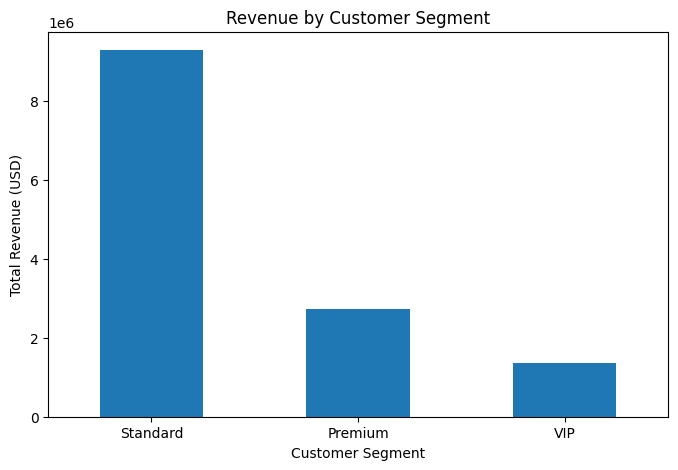

In [22]:
segment_revenue = (
    df.groupby("customer_segment")["total_order_value_usd"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_revenue)

plt.figure(figsize=(8,5))
segment_revenue.plot(kind="bar")
plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=0)
plt.show()

product_category
Electronics    7864399.26
Home           2670296.68
Clothing       1752583.94
Groceries       569155.51
Toys            523216.86
Name: total_order_value_usd, dtype: float64


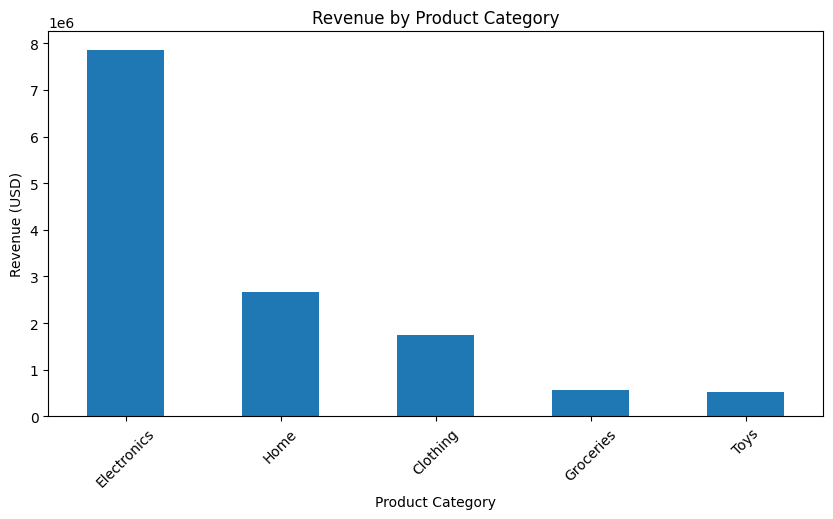

In [28]:
category_revenue = (
    df.groupby("product_category")["total_order_value_usd"]
      .sum()
      .sort_values(ascending=False)
)

print(category_revenue)

plt.figure(figsize=(10,5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.show()

shipping_method
Same-Day    1.438618
Express     1.245646
Standard    1.191300
Name: delivery_delay_days, dtype: float64


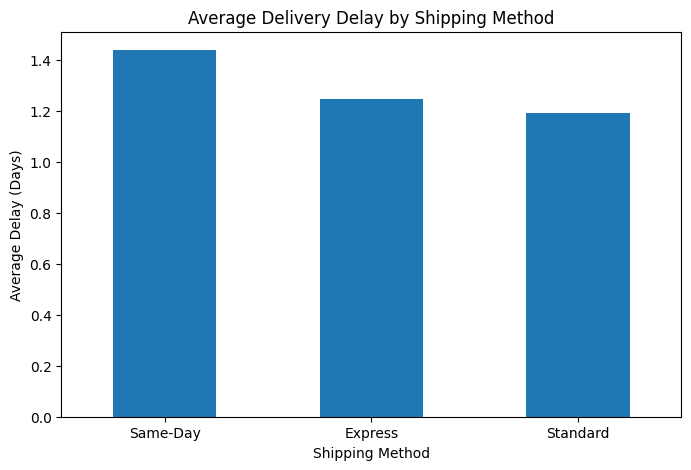

In [29]:
shipping_delay = (
    df.groupby("shipping_method")["delivery_delay_days"]
      .mean()
      .sort_values(ascending=False)
)

print(shipping_delay)

plt.figure(figsize=(8,5))
shipping_delay.plot(kind="bar")
plt.title("Average Delivery Delay by Shipping Method")
plt.xlabel("Shipping Method")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=0)
plt.show()

In [32]:
df["product_returned"] = df["product_returned"].map({
    "Yes": 1,
    "No": 0
})

shipping_method
Standard    4.369871
Express     4.363913
Same-Day    4.329268
Name: customer_review_score, dtype: float64


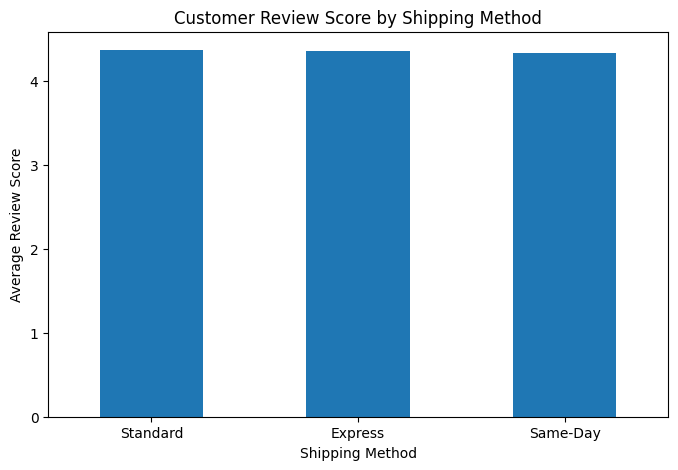

In [35]:
review = (
    df.groupby("shipping_method")["customer_review_score"]
      .mean()
      .sort_values(ascending=False)
)

print(review)

plt.figure(figsize=(8,5))
review.plot(kind="bar")
plt.title("Customer Review Score by Shipping Method")
plt.xlabel("Shipping Method")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)
plt.show()

In [37]:
print(df["fraud_flag"].unique())

['No' 'Yes']


In [38]:
df["fraud_flag"] = df["fraud_flag"].map({
    "Yes": 1,
    "No": 0
})

In [39]:
print("===== BUSINESS SUMMARY =====")

print(f"Total Orders: {len(df):,}")
print(f"Total Revenue: ${df['total_order_value_usd'].sum():,.2f}")
print(f"Average Order Value: ${df['total_order_value_usd'].mean():.2f}")
print(f"Average Delivery Delay: {df['delivery_delay_days'].mean():.2f} days")
print(f"Fraud Rate: {df['fraud_flag'].mean()*100:.2f}%")

===== BUSINESS SUMMARY =====
Total Orders: 24,999
Total Revenue: $13,379,652.25
Average Order Value: $535.21
Average Delivery Delay: 1.20 days
Fraud Rate: 3.06%
